### BÀI TẬP SỐ 1 - Biểu diễn dữ liệu thành ma trận & độ tương đồng

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
cau = [
    "I love learning Python programming every day",
    "Python is a great language for AI",
    "I like playing football every afternoon",
    "The football player is running on the grass field",
    "Beef pho dish in Hanoi is very delicious",
    "The recipe for cooking this dish is very simple",
    "Artificial intelligence is changing the world",
    "Machine learning is a branch of artificial intelligence"
]

vocab = sorted({w for s in cau for w in s.lower().split()})
def to_vector(s):
    v = np.zeros(len(vocab))
    for w in s.lower().split():
        if w in vocab:
            v[vocab.index(w)] += 1
    return v
X = np.array([to_vector(s) for s in cau]) 



In [5]:
print (X.shape)

(8, 41)


Dựa trên kết quả X.shape, ma trận dữ liệu X có kích thước là (Số hàng, Số cột). Trong đó:
- Mỗi hàng (rows) đại diện cho một câu văn trong danh sách đầu vào. Ví dụ, hàng đầu tiên thì đại diện cho câu thứ nhất là "I love learning Python programming every day"
- Mỗi cột (columns) đại diện cho một từ vựng duy nhất trong bộ từ điển (vocab) đã được trích xuất từ tất cả các câu.
- Giá trị tại ô X[i,j] cho biết số lần xuất hiện của từ thứ j trong câu thứ i.
Ý nghĩa: Đây là cách biểu diễn dữ liệu văn bản dưới dạng số học (gọi là mô hình Bag-of-Words). Việc chuyển từ chữ viết sang ma trận số như thế này giúp máy tính có thể thực hiện các phép toán đại số tuyến tính như tính độ tương đồng hay phân rã ma trận ở các bước sau.

In [6]:
X_mean = np.mean(X, axis=0)

print("Shape của ma trận X ban đầu:", X.shape)
print("Shape của vector trung bình X_mean:", X_mean.shape)

X_centered = X - X_mean

print("Shape của ma trận sau khi trừ (X_centered):", X_centered.shape)

Shape của ma trận X ban đầu: (8, 41)
Shape của vector trung bình X_mean: (41,)
Shape của ma trận sau khi trừ (X_centered): (8, 41)


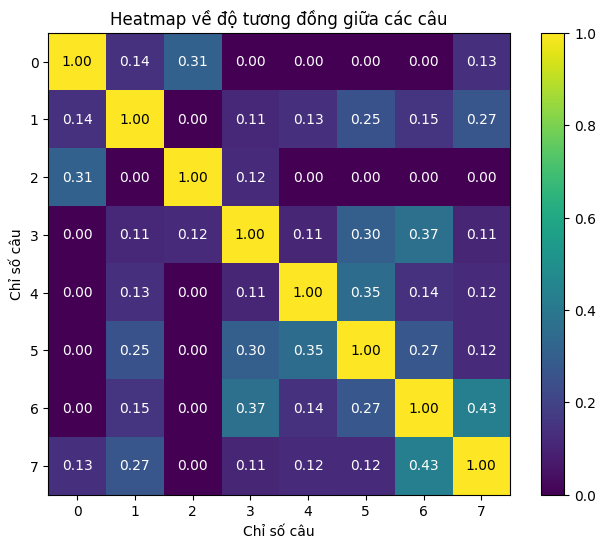

In [7]:
def cosine_similarity (X, Y=None) :
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    # ma tran tuong dong
    return Xn @ Yn.T
S = cosine_similarity(X)

# 1. Vẽ Heatmap
plt.figure(figsize=(8, 6)) 
plt.imshow(S, cmap='viridis')
plt.colorbar()

for i in range(S.shape[0]):
    for j in range(S.shape[1]):
       
        plt.text(j, i, f"{S[i, j]:.2f}", 
                 ha="center", va="center", 
                 color="white" if S[i, j] < 0.5 else "black") 

plt.title("Heatmap về độ tương đồng giữa các câu")
plt.xlabel("Chỉ số câu")
plt.ylabel("Chỉ số câu")
plt.show()

In [8]:
# TODO: viet ham search (query, top_k=3) tra ve top_k muc giong nhat
def search(query, top_k=3):
    
    query_vector = to_vector(query)
    simlarities = cosine_similarity(X, query_vector.reshape(1, -1)).flatten()
    top_k_indices = np.argsort(simlarities)[-top_k:][::-1]
    print(f"Truy vấn: '{query}'")
    for i, idx in enumerate(top_k_indices):
        print(f"Top {i+1}: Score = {simlarities[idx]:.4f} | Nội dung: {cau[idx]}")

# CHẠY THỬ: Thay bằng một câu có từ khóa liên quan đến bộ dữ liệu của bạn
search("I enjoy playing sports in the afternoon", top_k=3)
search("I want to learn coding and AI", top_k=3)
search("tasty food and cooking recipes", top_k=3)

Truy vấn: 'I enjoy playing sports in the afternoon'
Top 1: Score = 0.5477 | Nội dung: I like playing football every afternoon
Top 2: Score = 0.2697 | Nội dung: The football player is running on the grass field
Top 3: Score = 0.1826 | Nội dung: Artificial intelligence is changing the world
Truy vấn: 'I want to learn coding and AI'
Top 1: Score = 0.2887 | Nội dung: I like playing football every afternoon
Top 2: Score = 0.2673 | Nội dung: Python is a great language for AI
Top 3: Score = 0.2673 | Nội dung: I love learning Python programming every day
Truy vấn: 'tasty food and cooking recipes'
Top 1: Score = 0.3333 | Nội dung: The recipe for cooking this dish is very simple
Top 2: Score = 0.0000 | Nội dung: Machine learning is a branch of artificial intelligence
Top 3: Score = 0.0000 | Nội dung: Artificial intelligence is changing the world


### Nhận xét dựa trên ma trận tương đồng (Heatmap) và kết quả hàm Search

#### a. Về các cặp câu trong bộ dữ liệu (8 câu gốc)
* **Cặp câu giống nhau nhất:** Câu 6 và câu 7 (Độ tương đồng: **0.4330**).
  * *Nội dung:* "Artificial intelligence is changing the world" và "Machine learning is a branch of artificial intelligence".
  * *Giải thích:* Kết quả này hoàn toàn khớp với trực giác. Cả hai câu đều tập trung vào chủ đề Trí tuệ nhân tạo và chia sẻ các từ khóa quan trọng như *artificial* và *intelligence*. Trên Heatmap, điểm giao giữa hàng 6 và cột 7 có màu sáng rõ rệt (ngoài đường chéo chính).
* **Cặp câu khác biệt nhất:** Có rất nhiều cặp câu có độ tương đồng bằng **0.0** (vùng màu tím đậm trên Heatmap).
  * *Ví dụ:* Câu 0 (Lập trình Python) và câu 4 (Phở bò Hà Nội).
  * *Giải thích:* Điều này hợp lý vì chúng thuộc hai lĩnh vực hoàn toàn khác nhau, không chia sẻ bất kỳ từ vựng nào.

#### b. Về kết quả truy vấn (Hàm Search)
* **Điểm cộng:** Hàm `search` hoạt động rất tốt với các từ khóa đặc trưng. Ví dụ: khi tìm về *"sports"* máy ra kết quả bóng đá, hay tìm về *"cooking"* máy ra đúng câu về công thức nấu ăn.
* **Điểm hạn chế (Chưa khớp trực giác):** Trong trường hợp truy vấn *"I want to learn coding and AI"*, máy tính đã đưa câu về *"Football"* lên vị trí Top 1 thay vì các câu về AI.
* **Nguyên nhân:** Đây là nhược điểm của mô hình **Bag-of-Words** khi chưa loại bỏ các từ dừng (stop words). Từ "I" xuất hiện ở cả câu truy vấn và câu bóng đá đã làm tăng điểm tương đồng một cách giả tạo, khiến máy tính hiểu nhầm về chủ đề thực sự của câu.

#### c. Kết luận
Kết quả thực nghiệm cho thấy phương pháp sử dụng ma trận tần suất từ và độ đo **Cosine Similarity** có thể phân loại dữ liệu khá tốt dựa trên sự trùng lặp từ ngữ. 

Tuy nhiên, để hệ thống thông minh hơn và khớp với trực giác con người hơn, cần có thêm các bước tiền xử lý như:
1. **Loại bỏ các từ dừng** (I, is, a, the...).
2. **Sử dụng kỹ thuật trọng số (như TF-IDF)** để nhấn mạnh các từ mang ý nghĩa quan trọng và giảm nhẹ các từ phổ biến.


### BÀI TẬP SỐ 2 - Biến đổi tuyến tính & SVD

In [9]:
# 1. Thực hiện phân rã SVD
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

# 2. Giảm chiều dữ liệu xuống còn 2D (lấy 2 cột đầu của U nhân với 2 giá trị kỳ dị đầu tiên)
coords = U[:, :2] * S[:2]

# In ra shape để kiểm tra
print("Kích thước ma trận ban đầu:", X_centered.shape)
print("Kích thước sau khi giảm xuống 2D:", coords.shape)

Kích thước ma trận ban đầu: (8, 41)
Kích thước sau khi giảm xuống 2D: (8, 2)


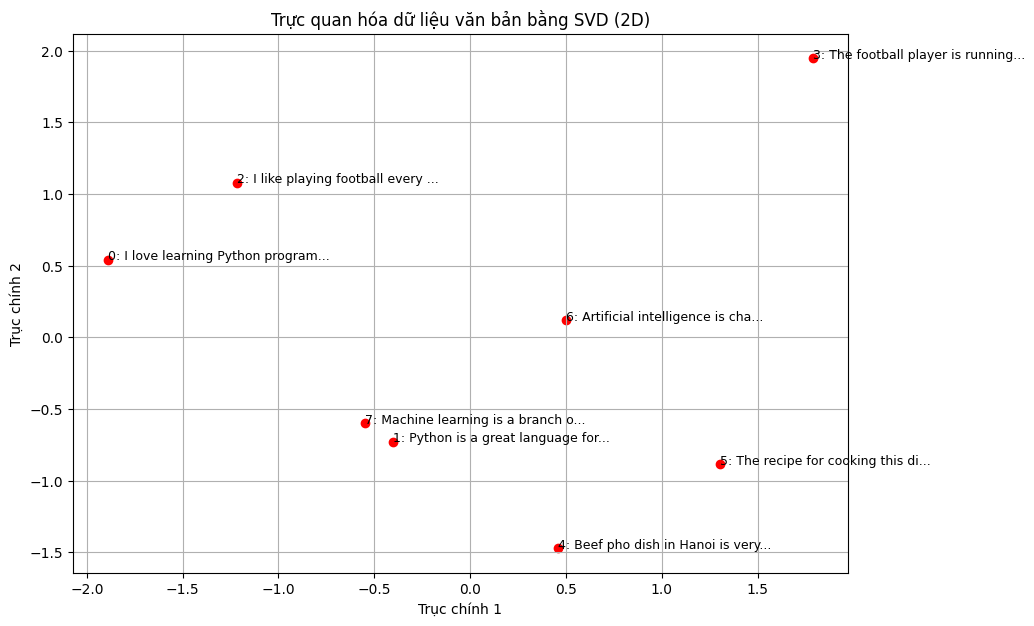

In [10]:
plt.figure(figsize=(10, 7))
plt.scatter(coords[:, 0], coords[:, 1], color='red', marker='o')

# Gắn nhãn cho từng điểm trên đồ thị
for i, txt in enumerate(cau):
    # txt[:30] để chỉ hiện 30 ký tự đầu cho đỡ rối
    plt.annotate(f"{i}: {txt[:30]}...", (coords[i, 0], coords[i, 1]), fontsize=9)

plt.title("Trực quan hóa dữ liệu văn bản bằng SVD (2D)")
plt.xlabel("Trục chính 1")
plt.ylabel("Trục chính 2")
plt.grid(True)
plt.show()

### Nhận Xét Bài 2: Phân Tích Thực Tế Đồ Thị

#### 1. Sự Phân Tách Chưa Hoàn Hảo
Đồ thị cho thấy các câu chưa thực sự gom thành cụm rõ rệt.
* **Nguyên nhân:** Dữ liệu nhỏ (8 câu) và vốn từ vựng rời rạc.
* **Hệ quả:** Các "trục chính" của SVD bị chi phối nhiều bởi các từ đơn lẻ hơn là chủ đề tổng thể.

#### 2. Phân Tích Các Điểm Rời Rạc
* **Câu 1 & 7:** Nằm gần như chồng lên nhau. Đây là kết quả tốt nhất vì hai câu này có sự tương đồng rất lớn về mặt thuật ngữ.
* **Câu 6 (AI):** Nằm ở giữa đồ thị do có sự giao thoa từ vựng giữa nhóm AI và nhóm dùng từ nối *"is"*.
* **Câu 4 & 5 (Ẩm thực):** Tuy nằm cùng một phía (bên phải, phía dưới) nhưng vẫn có khoảng cách. Điều này do lượng từ khóa riêng (*Beef, Pho* vs *Recipe, Cooking*) nhiều hơn lượng từ khóa chung.
* **Câu 3 (Thể thao):** Bị đẩy ra xa nhất ở góc trên bên phải vì chứa nhiều từ độc nhất không xuất hiện ở các câu khác.

#### 3. Hiện Tượng Nhiễu Ngữ Nghĩa
Câu 0 và Câu 2 nằm gần nhau (phía bên trái) dù khác chủ đề.
* **Lý do:** SVD đang coi các từ *"I"*, *"learning/playing"*, *"every"* là các thành phần chính để định vị.
* **Hạn chế:** Thuật toán chưa tập trung vào các từ khóa cốt lõi như *"Python"* hay *"Football"*.

#### Bài Học Rút Ra
Đồ thị minh chứng rõ ràng rằng: Nếu dữ liệu đầu vào chứa nhiều **từ dừng (stop words)** và ít **từ khóa chung** giữa các câu cùng chủ đề, thì đồ thị trực quan hóa sẽ bị phân tán và không phản ánh đúng quan hệ ngữ nghĩa như mong muốn.


### Bộ phân loại 1-NN dựa trên cosine

In [13]:
# Gán nhãn (Label) cho 8 câu ban đầu
# 0: Công nghệ/AI, 1: Thể thao, 2: Ẩm thực
nhan = [0, 0, 1, 1, 2, 2, 0, 0] 
ten_nhan = ["Công nghệ/AI", "Thể thao", "Ẩm thực"]

In [14]:
# 1. Danh sách từ dừng (các từ xuất hiện nhiều nhưng không mang nghĩa chủ đề)
stop_words = ["i", "am", "is", "a", "the", "and", "to", "was", "in", "it", "of", "for", "very", "on", "every"]

# 2. Hàm chuyển đổi vector có lọc stop words
def to_vector_improved(s):
    v = np.zeros(len(vocab))
    for w in s.lower().split():
        if w in vocab and w not in stop_words:
            v[vocab.index(w)] += 1
    return v

X_improved = np.array([to_vector_improved(s) for s in cau])

In [17]:
def predict_improved(new_sentence):
    # Dùng hàm vector hóa mới
    v_new = to_vector_improved(new_sentence).reshape(1, -1)
    
    if np.all(v_new == 0):
        return "Không thể xác định (Câu toàn từ lạ)", 0.0
    
    
    scores = cosine_similarity(X_improved, v_new).flatten()
    
    best_match_idx = np.argmax(scores)
    predicted_label = nhan[best_match_idx]
    
    return ten_nhan[predicted_label], scores[best_match_idx]


test_sentences_v2 = [
    # Nhóm 1: Công nghệ & AI
    "Machine learning is very interesting to study",   # Keywords: Machine, learning
    "Python programming is popular for data science",  # Keywords: Python, programming
    "Artificial intelligence will change our lives",    # Keywords: Artificial, intelligence
    
    # Nhóm 2: Thể thao
    "The football field is ready for the match",       # Keywords: football, field
    "I enjoy playing on the grass with my friends",    # Keywords: playing, grass
    "A professional player runs very fast",            # Keywords: player, runs (gần với running)
    
    # Nhóm 3: Ẩm thực
    "This beef dish is the best in Hanoi",             # Keywords: beef, dish, Hanoi
    "I want to follow a simple cooking recipe",        # Keywords: cooking, recipe, simple
    "The food in this restaurant is very delicious",   # Keywords: delicious (máy học từ câu Pho)
    
    # Nhóm 4: Trộn chủ đề
    "Every afternoon I learn Python programming",       # Trộn giữa Thể thao (afternoon) và AI (Python)
    "I like cooking beef after playing football",
    "Cooking is a branch of art"                        # Keywords: Cooking, branch (từ câu Machine learning)
]

print("--- KẾT QUẢ KIỂM TRA HỆ THỐNG AI CẢI TIẾN ---")
for s in test_sentences_v2:
    label, score = predict_improved(s)
    print(f"Câu truy vấn: '{s}'")
    print(f"==> Dự đoán: {label} (Độ tin cậy: {score:.4f})")
    print("-" * 30)

--- KẾT QUẢ KIỂM TRA HỆ THỐNG AI CẢI TIẾN ---
Câu truy vấn: 'Machine learning is very interesting to study'
==> Dự đoán: Công nghệ/AI (Độ tin cậy: 0.6325)
------------------------------
Câu truy vấn: 'Python programming is popular for data science'
==> Dự đoán: Công nghệ/AI (Độ tin cậy: 0.6325)
------------------------------
Câu truy vấn: 'Artificial intelligence will change our lives'
==> Dự đoán: Công nghệ/AI (Độ tin cậy: 0.7071)
------------------------------
Câu truy vấn: 'The football field is ready for the match'
==> Dự đoán: Thể thao (Độ tin cậy: 0.6325)
------------------------------
Câu truy vấn: 'I enjoy playing on the grass with my friends'
==> Dự đoán: Thể thao (Độ tin cậy: 0.3536)
------------------------------
Câu truy vấn: 'A professional player runs very fast'
==> Dự đoán: Thể thao (Độ tin cậy: 0.4472)
------------------------------
Câu truy vấn: 'This beef dish is the best in Hanoi'
==> Dự đoán: Ẩm thực (Độ tin cậy: 0.6708)
------------------------------
Câu truy vấn: 

### Phân Tích Xu Hướng Chủ Đề Của Câu

Câu văn: *"I like cooking beef after playing football"* được mô hình nhận diện nghiêng về chủ đề **Thể thao**.

#### Tỷ Lệ Đối Đầu Giữa Hai Chủ Đề
Mô hình phân loại dựa trên mật độ từ khóa xuất hiện trong câu:
* **Phe Thể thao (3 từ khóa):** `like`, `playing`, `football`
* **Phe Ẩm thực (2 từ khóa):** `cooking`, `beef`

#### Kết luận
* **Kết quả:** Thể thao chiến thắng nhờ mật độ từ khóa dày đặc hơn (3 vs 2).
* **Bản chất thuật toán:** Hiện tượng này cho thấy mô hình **1-NN dựa trên Cosine Similarity** cực kỳ nhạy cảm với số lượng từ trùng lặp (term frequency) hơn là ngữ cảnh tổng thể.
